In [1]:
# This is the code Alex used to processed the IFF ASDEX data and find the link distributions

# # The path to the csv file
# data_path = "/Users/alexporcayo/Documents/python/IFF_ATL+ASDEX_20230506.csv"
# node_path = "/Users/alexporcayo/Documents/python/KATL_Nodes_Def.csv"
# links_path = "/Users/alexporcayo/Documents/python/KATL_Nodes_Links (1).csv"
# output_path = "/Users/alexporcayo/Documents/python/linkdata.csv"
# data_path_EV= "/Users/alexporcayo/Documents/python/EV_ATL_20230506.csv"
# data_path_AD= "/Users/alexporcayo/Documents/python/.csv"
# df = spark.read.csv(data_path, header=False, sep=",", schema=iff_schema)
# cols = ['recType', 'recTime', 'acId', 'lat', 'lon', 'alt','groundSpeed']
# colsEV =['tStartSecs','tStopSecs','AcId','AcType']
# df = df.select(*cols).filter(df['recType']==3).withColumn("recTime", df['recTime'].cast(IntegerType()))
# EV_df= spark.read.csv(data_path_EV, header=True, inferSchema=True)
# EV_df=EV_df.select(*colsEV)
# EV_df=EV_df.withColumn("tStartSecs", EV_df['tStartSecs'].cast(IntegerType()))
# EV_df=EV_df.withColumn("tStopSecs", EV_df['tStopSecs'].cast(IntegerType()))
# # Define your coordinate boundaries
# min_lon, max_lon = -84.45610, -84.40284
# min_lat, max_lat = 33.61556, 33.65534
# # Filter the DataFrame using column conditions
# df = df.filter((df["lon"] >= min_lon) &
#                     (df["lon"] <= max_lon) &
#                     (df["lat"] >= min_lat) &
#                     (df["lat"] <= max_lat))
# # Define the time section Saturday, May 6, 2023 7:00:00 AM GMT-05:00 TO Saturday, May 6, 2023 8:00:00 AM GMT-05:00
# min_T , max_T = 1683374400,1683378000
# # Filter the DataFrame using column conditions
# df = df.filter((df["recTime"] >= min_T) &
#                     (df["recTime"] <= max_T))
# EV_df =EV_df.filter((EV_df["tStartSecs"] >= min_T) &
#                     (EV_df["tStartSecs"] <= max_T))
# EV_df=EV_df.dropDuplicates()
# EV_df.createOrReplaceTempView("EV")
# # Convert the epoch timestamp to a proper timestamp type
# # This creates a new column "timestamp" as a Spark timestamp.
# df = df.withColumn("recTime", from_unixtime(col("recTime")).cast("timestamp"))
# df = df.withColumn("geometry", expr("ST_Point(CAST(lon AS Decimal(24,20)), CAST(lat AS Decimal(24,20)))"))
# df.createOrReplaceTempView("ASDEX")
# nodes_df = spark.read.csv(node_path, header=True, inferSchema=True)
# links_df = spark.read.csv(links_path, header=True, inferSchema=True)
# nodes_df.createOrReplaceTempView("nodes")
# links_df.createOrReplaceTempView("links")
# nodes_with_geom = spark.sql("""
#     SELECT id, index, lon, lat, ST_Point(lon, lat) AS geom
#     FROM nodes
# """)
# nodes_with_geom.createOrReplaceTempView("NODE")
# # links_with_geom = spark.sql("""
# #     SELECT `n1.index`, `n2.index`
# #     FROM links
# # """)
# links_geom = spark.sql("""
#     SELECT `n1.index`,`n2.index`, link_name,
#     s.geom AS start_geometry,
#     e.geom AS end_geometry,
#     ST_MakeLine(s.geom, e.geom) AS link_geometry
#     FROM links
#     JOIN NODE s ON `n1.index` = s.index
#     JOIN NODE e ON `n2.index` = e.index
# """)
# links_geom.createOrReplaceTempView("LINKS")
# # We use ST_Distance to join ASDE-X records with points that lie within a given threshold.
# point_threshold = 0.00025  # Adjust threshold based on your data's spatial resolution
# asdex_points = spark.sql(f"""
# SELECT a.*, p.index ,p.id
# FROM ASDEX a, NODE p
# WHERE ST_Distance(a.geometry, p.geom) < {point_threshold}
# """)
# asdex_points.createOrReplaceTempView("asdex_points")
# #asdex_points.show(truncate=False)
# # =========================
# # Step 6: Spatial Join - Associate ASDE-X Data with Runway Links
# # =========================
# # Similarly, assign records to links if they are within a threshold distance.
# link_threshold = 0.00001  # Adjust threshold as needed
# asdex_links = spark.sql(f"""
# SELECT a.recTime, a.acId,a.groundSpeed, l.`n1.index`,l.`n2.index`, l.link_geometry, l.link_name
# FROM ASDEX a, LINKS l
# WHERE ST_Distance(a.geometry, l.link_geometry) < {link_threshold}
# """)
# asdex_links.createOrReplaceTempView("asdex_links")
# #asdex_links.show(truncate=False)
# # =========================
# # Step 7: Compute Time Distribution per Runway Point
# # =========================
# # For each aircraft and each runway point, compute the entry (min timestamp) and exit (max timestamp)
# # then calculate the duration (in seconds) spent near that point.
# point_time_df = spark.sql("""
# SELECT acId, index, id,
#        MIN(recTime) AS entry_time,
#        MAX(recTime) AS exit_time,
#        unix_timestamp(MAX(recTime)) - unix_timestamp(MIN(recTime)) AS duration_seconds,
#        AVG(groundSpeed) AS avg_speed
# FROM asdex_points
# GROUP BY acId, index, id
# ORDER BY acId, index
# """)
# point_time_df.createOrReplaceTempView("point_time")
# #point_time_df.show(truncate=False)
# # =========================
# # Step 8: Compute Time Distribution per Runway Link
# # =========================
# # Similarly, for each aircraft and each link, calculate the duration spent near that link.
# link_time_df = spark.sql("""
# SELECT a.acId, a.link_name,
#        MIN(a.recTime) AS entry_time,
#        MAX(a.recTime) AS exit_time,
#        unix_timestamp(MAX(a.recTime)) - unix_timestamp(MIN(a.recTime)) AS duration_seconds,
#        round(AVG(a.groundSpeed),4) AS avg_speed,
#        ev.AcType AS actype
# FROM asdex_links a
# LEFT JOIN EV ev ON a.acId = ev.AcId
# GROUP BY a.acId, a.link_name, ev.AcType
# ORDER BY acId,entry_time
# """)
# link_time_df.createOrReplaceTempView("link_time")
# #link_time_df.show(truncate=False)
# #==================================================
# link_speed_df = spark.sql("""
# SELECT link_name, avg_speed, actype
# FROM link_time
# ORDER BY link_name, actype
# """)
# link_speed_df.createOrReplaceTempView("link_speed")
# link_speed_df.write.csv(output_path, header=True, mode="overwrite")

### We are interested in the overlaping links based on the KATL taxiway collision case. That is,
- Txy_E_004 to Txy_E_003 
- Txy_E_003 to Txy_E_002

And these correponding to index 392/391/390 from the node-link file. 

In [2]:
# change data file to plot figures
date = '05112023'

Lognormal fitted parameters: shape=0.5182, loc=0.0000, scale=8.7969
Mu (log scale): 2.1744005742192485
Sigma (shape): 0.5181648059683244
Normal fitted parameters: mean=9.9191, std=4.6568
Lognormal KS statistic: 0.0703, p-value: 0.1513
Normal KS statistic: 0.0853, p-value: 0.0454


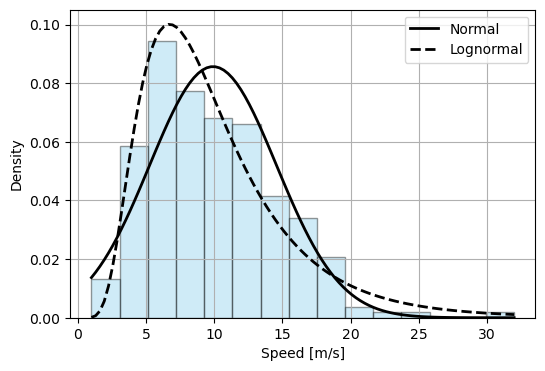

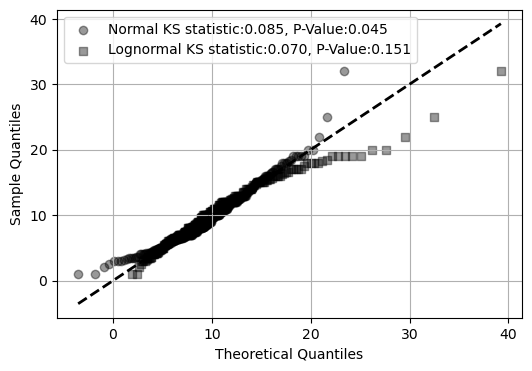

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# import scienceplots
# plt.style.use('science')

# --- Load the CSV Files ---
data_paths = [f"/home/yp6443/research/nlp/linktime_data/{date}-linkdata.csv"]
# data_paths = [
#     # "/home/yp6443/research/nlp/linktime_data/05062023-linkdata.csv", # n/a
#     # "/home/yp6443/research/nlp/linktime_data/05072023-linkdata.csv", # lognormal
#     # "/home/yp6443/research/nlp/linktime_data/05082023-linkdata.csv", # lognormal
#     # "/home/yp6443/research/nlp/linktime_data/05092023-linkdata.csv", # lognormal
#     # "/home/yp6443/research/nlp/linktime_data/05102023-linkdata.csv", # lognormal
#     # "/home/yp6443/research/nlp/linktime_data/05112023-linkdata.csv", # lognormal
#     "/home/yp6443/research/nlp/linktime_data/05122023-linkdata.csv", # normal
# ]

# Read each CSV file and store the resulting DataFrame in a list
dfs = [pd.read_csv(file) for file in data_paths]
df = pd.concat(dfs, ignore_index=True)
df.count()

# --- Filter Data for the Target Link ---
target_link = "390_391"  # Change this to your desired link
df_link = df[df['link_name'] == target_link].dropna(subset=['avg_speed'])

if df_link.empty:
    print(f"No data found for link '{target_link}'.")
else:
    speeds = df_link['avg_speed'].astype(float)
    
    # --- Fit Lognormal Distribution (forcing loc=0) ---
    shape, loc, scale = stats.lognorm.fit(speeds, floc=0)
    print(f"Lognormal fitted parameters: shape={shape:.4f}, loc={loc:.4f}, scale={scale:.4f}")
    print("Mu (log scale):", np.log(scale))
    print("Sigma (shape):", shape)
    
    # --- Fit Normal Distribution ---
    mu_norm, sigma_norm = stats.norm.fit(speeds)
    print(f"Normal fitted parameters: mean={mu_norm:.4f}, std={sigma_norm:.4f}")
    
    # --- Kolmogorov-Smirnov Test for Lognormal Fit ---
    log_ks_stat, log_ks_pvalue = stats.kstest(speeds, 'lognorm', args=(shape, loc, scale))
    print(f"Lognormal KS statistic: {log_ks_stat:.4f}, p-value: {log_ks_pvalue:.4f}")
    
    norm_ks_stat, norm_ks_pvalue = stats.kstest(speeds, 'norm', args=(mu_norm, sigma_norm))
    print(f"Normal KS statistic: {norm_ks_stat:.4f}, p-value: {norm_ks_pvalue:.4f}")
    
    # Define x values over the range of speeds
    x = np.linspace(speeds.min(), speeds.max(), 100)
    
    # Compute PDFs for both fits
    pdf_lognorm = stats.lognorm.pdf(x, shape, loc=loc, scale=scale)
    pdf_norm = stats.norm.pdf(x, mu_norm, sigma_norm)
    
    # --- Plot Histogram and Both Fits ---
    fig, ax = plt.subplots(figsize=(6, 4))
    
    # Plot histogram on left y-axis (density normalized)
    n, bins, patches = ax.hist(speeds, bins=15, density=True, alpha=0.4, 
                                color='skyblue', edgecolor='black')
    ax.set_xlabel('Speed [m/s]')
    ax.set_ylabel('Density')
    
    # Plot the normal fit on the same axis using a dashed line
    ax.plot(x, pdf_norm, 'k', lw=2, label=f'Normal')
    
    # Create a second y-axis for the lognormal density
    # ax2 = ax1.twinx()
    ax.plot(x, pdf_lognorm, 'k--', lw=2, label=f'Lognormal')
    # ax2.set_ylabel('Lognormal Density')
    
    # Combine legends from both axes
    lines1, labels1 = ax.get_legend_handles_labels()
    # lines2, labels2 = ax2.get_legend_handles_labels()
    # ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
    plt.legend()
    # plt.title(f'Speed Distribution with Normal and Lognormal Fits\nLink: {target_link}')
    plt.grid(True)
    plt.savefig(f'./figs/{target_link}_{date}_hist.png', dpi=300)
    plt.show()
    
    # --- Combined Q-Q Plot for Both Normal and Lognormal Fits ---
    # Sort the speeds and compute plotting positions
    sorted_speeds = np.sort(speeds)
    n_points = len(speeds)
    p = (np.arange(1, n_points + 1) - 0.5) / n_points
    
    # Compute theoretical quantiles for the Normal and Lognormal fits
    q_norm = stats.norm.ppf(p, loc=mu_norm, scale=sigma_norm)
    q_lognorm = stats.lognorm.ppf(p, shape, loc=loc, scale=scale)
    
    fig, ax = plt.subplots(figsize=(6, 4))
    # Plot Normal Q-Q points in green (circle markers)
    ax.scatter(q_norm, sorted_speeds, color='black', marker='o', label=f'Normal KS statistic:{norm_ks_stat:.3f}, P-Value:{norm_ks_pvalue:.3f}', alpha=0.4)
    # Plot Lognormal Q-Q points in red (square markers)
    ax.scatter(q_lognorm, sorted_speeds, color='black', marker='s', label=f'Lognormal KS statistic:{log_ks_stat:.3f}, P-Value:{log_ks_pvalue:.3f}', alpha=0.4)
    
    # Plot the 45° reference line covering the union of theoretical quantiles
    all_theoretical = np.concatenate([q_norm, q_lognorm])
    x_min = np.min(all_theoretical)
    x_max = np.max(all_theoretical)
    ax.plot([x_min, x_max], [x_min, x_max], 'k--', lw=2)
    
    ax.set_xlabel('Theoretical Quantiles')
    ax.set_ylabel('Sample Quantiles')
    # ax.set_title('Combined Q-Q Plot for Normal and Lognormal Fits')
    ax.legend(loc='best')
    ax.grid(True)
    plt.savefig(f'./figs/{target_link}_{date}_qq.png', dpi=300)
    plt.show()
    


Lognormal fitted parameters: shape=0.3725, loc=0.0000, scale=11.4808
Mu (log scale): 2.440679478163006
Sigma (shape): 0.3725423499033288
Normal fitted parameters: mean=12.3035, std=4.6511
Lognormal KS statistic: 0.0570, p-value: 0.3409
Normal KS statistic: 0.1093, p-value: 0.0032


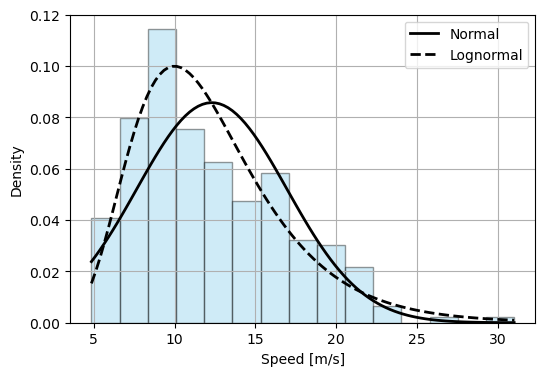

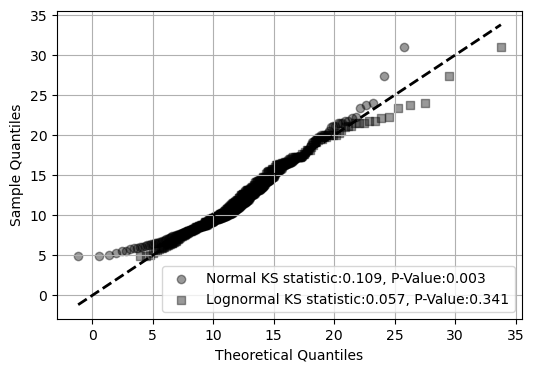

In [4]:
# --- Filter Data for the Target Link ---
target_link = "391_392"  # Change this to your desired link
df_link = df[df['link_name'] == target_link].dropna(subset=['avg_speed'])

if df_link.empty:
    print(f"No data found for link '{target_link}'.")
else:
    speeds = df_link['avg_speed'].astype(float)
    
    # --- Fit Lognormal Distribution (forcing loc=0) ---
    shape, loc, scale = stats.lognorm.fit(speeds, floc=0)
    print(f"Lognormal fitted parameters: shape={shape:.4f}, loc={loc:.4f}, scale={scale:.4f}")
    print("Mu (log scale):", np.log(scale))
    print("Sigma (shape):", shape)
    
    # --- Fit Normal Distribution ---
    mu_norm, sigma_norm = stats.norm.fit(speeds)
    print(f"Normal fitted parameters: mean={mu_norm:.4f}, std={sigma_norm:.4f}")
    
    # --- Kolmogorov-Smirnov Test for Lognormal Fit ---
    log_ks_stat, log_ks_pvalue = stats.kstest(speeds, 'lognorm', args=(shape, loc, scale))
    print(f"Lognormal KS statistic: {log_ks_stat:.4f}, p-value: {log_ks_pvalue:.4f}")
    
    norm_ks_stat, norm_ks_pvalue = stats.kstest(speeds, 'norm', args=(mu_norm, sigma_norm))
    print(f"Normal KS statistic: {norm_ks_stat:.4f}, p-value: {norm_ks_pvalue:.4f}")
    
    # Define x values over the range of speeds
    x = np.linspace(speeds.min(), speeds.max(), 100)
    
    # Compute PDFs for both fits
    pdf_lognorm = stats.lognorm.pdf(x, shape, loc=loc, scale=scale)
    pdf_norm = stats.norm.pdf(x, mu_norm, sigma_norm)
    
    # --- Plot Histogram and Both Fits ---
    fig, ax = plt.subplots(figsize=(6, 4))
    
    # Plot histogram on left y-axis (density normalized)
    n, bins, patches = ax.hist(speeds, bins=15, density=True, alpha=0.4, 
                                color='skyblue', edgecolor='black')
    ax.set_xlabel('Speed [m/s]')
    ax.set_ylabel('Density')
    
    # Plot the normal fit on the same axis using a dashed line
    ax.plot(x, pdf_norm, 'k', lw=2, label=f'Normal')
    
    # Create a second y-axis for the lognormal density
    # ax2 = ax1.twinx()
    ax.plot(x, pdf_lognorm, 'k--', lw=2, label=f'Lognormal')
    # ax2.set_ylabel('Lognormal Density')
    
    # Combine legends from both axes
    lines1, labels1 = ax.get_legend_handles_labels()
    # lines2, labels2 = ax2.get_legend_handles_labels()
    # ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
    plt.legend()
    # plt.title(f'Speed Distribution with Normal and Lognormal Fits\nLink: {target_link}')
    plt.grid(True)
    plt.savefig(f'./figs/{target_link}_{date}_hist.png', dpi=300)
    plt.show()
    
    # --- Combined Q-Q Plot for Both Normal and Lognormal Fits ---
    # Sort the speeds and compute plotting positions
    sorted_speeds = np.sort(speeds)
    n_points = len(speeds)
    p = (np.arange(1, n_points + 1) - 0.5) / n_points
    
    # Compute theoretical quantiles for the Normal and Lognormal fits
    q_norm = stats.norm.ppf(p, loc=mu_norm, scale=sigma_norm)
    q_lognorm = stats.lognorm.ppf(p, shape, loc=loc, scale=scale)
    
    fig, ax = plt.subplots(figsize=(6, 4))
    # Plot Normal Q-Q points in green (circle markers)
    ax.scatter(q_norm, sorted_speeds, color='black', marker='o', label=f'Normal KS statistic:{norm_ks_stat:.3f}, P-Value:{norm_ks_pvalue:.3f}', alpha=0.4)
    # Plot Lognormal Q-Q points in red (square markers)
    ax.scatter(q_lognorm, sorted_speeds, color='black', marker='s', label=f'Lognormal KS statistic:{log_ks_stat:.3f}, P-Value:{log_ks_pvalue:.3f}', alpha=0.4)
    
    # Plot the 45° reference line covering the union of theoretical quantiles
    all_theoretical = np.concatenate([q_norm, q_lognorm])
    x_min = np.min(all_theoretical)
    x_max = np.max(all_theoretical)
    ax.plot([x_min, x_max], [x_min, x_max], 'k--', lw=2)
    
    ax.set_xlabel('Theoretical Quantiles')
    ax.set_ylabel('Sample Quantiles')
    # ax.set_title('Combined Q-Q Plot for Normal and Lognormal Fits')
    ax.legend(loc='best')
    ax.grid(True)
    plt.savefig(f'./figs/{target_link}_{date}_qq.png', dpi=300)
    plt.show()

# Further Study based on weight class

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os
import glob

data_paths = [
    "/home/yp6443/research/nlp/linktime_data/05062023-linkdata.csv", # n/a
    "/home/yp6443/research/nlp/linktime_data/05072023-linkdata.csv", # lognormal
    "/home/yp6443/research/nlp/linktime_data/05082023-linkdata.csv", # lognormal
    "/home/yp6443/research/nlp/linktime_data/05092023-linkdata.csv", # lognormal
    "/home/yp6443/research/nlp/linktime_data/05102023-linkdata.csv", # lognormal
    "/home/yp6443/research/nlp/linktime_data/05112023-linkdata.csv", # lognormal
    "/home/yp6443/research/nlp/linktime_data/05122023-linkdata.csv", # normal
]

target_link = "391_392"  # Change this to your desired link

# Read each CSV file and store the resulting DataFrame in a list
dfs = [pd.read_csv(file) for file in data_paths]
df = pd.concat(dfs, ignore_index=True)

# --- Step 2: Load the Weight Class Reference CSV ---
# Update this file path to your weight class reference file.
df_ref = pd.read_excel('/home/yp6443/research/nlp/linktime_data/aircraft_weightclass_data.xlsx', sheet_name='ACD_Data')
# df_ref = pd.read_csv(ref_file)

# For consistency, ensure the FAA_Designator column is uppercase.
df_ref['FAA_Designator'] = df_ref['FAA_Designator'].astype(str).str.upper()

/home/yp6443/anaconda3/envs/nlp/lib/python3.10/site-packages/openpyxl/worksheet/_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():
/home/yp6443/anaconda3/envs/nlp/lib/python3.10/site-packages/openpyxl/worksheet/_read_only.py:85: UserWarning: Conditional Formatting extension is not supported and will be removed
  for idx, row in parser.parse():


In [6]:
# --- Step 3: Define a Function to Assign Weight Class ---
def get_weight_class_from_ref(actype, ref_df):
    """
    Looks up the FAA_Designator in the reference DataFrame and returns the FAA_Weight value.
    If the actype is missing or not found in the reference, returns 'Unknown'.
    """
    if pd.isnull(actype) or str(actype).strip() in ['?', '']:
        return 'Unknown'
    code = str(actype).strip().upper()
    # print(code)
    # Look up the reference row matching this FAA_Designator
    row = ref_df[ref_df['FAA_Designator'] == code]
    
    if row.empty:
        return 'Unknown'
    try:
        weight = row.iloc[0]['FAA_Weight']
        return weight
    except Exception as e:
        return 'Unknown'
    

# --- Step 4: Filter for the Target Link and Analyze by Weight Class ---
df_link = df[df['link_name'] == target_link].dropna(subset=['avg_speed'])

# Apply the function to create a new column "weight_class" in the main DataFrame.
# Assume the column storing the aircraft designator is named 'actype'.
df_link['weight_class'] = df_link['actype'].apply(lambda x: get_weight_class_from_ref(x, df_ref))

In [7]:
df_link

,link_name,avg_speed,actype,weight_class
27728,391_392,6.2195,?,Unknown
27729,391_392,27.7647,?,Unknown
27730,391_392,15.0000,?,Unknown
27731,391_392,21.8182,A20N,Large
27732,391_392,25.2000,A20N,Large
...,...,...,...,...
250371,391_392,11.6250,CRJ9,Large
250372,391_392,13.1000,CRJ9,Large
250373,391_392,9.1333,CRJ9,Large
250374,391_392,9.7368,CRJ9,Large


In [8]:
import pandas as pd
from scipy import stats

# Assume your DataFrame is named 'df'
# Ensure there are no missing values in the relevant columns
df_link = df_link.dropna(subset=['avg_speed', 'weight_class'])

# Group the avg_speed by weight_class
groups = df_link.groupby('weight_class')['avg_speed'].apply(list)

# Check the number of unique weight classes
num_groups = len(groups)
print(f"Link: {target_link}")
print(f"Number of weight classes: {num_groups}")

if num_groups == 2:
    # If there are exactly two groups, perform an independent t-test
    group1, group2 = groups.iloc[0], groups.iloc[1]
    t_stat, p_val = stats.ttest_ind(group1, group2, equal_var=False)  # Welch's t-test (doesn't assume equal variances)
    print("T-test Results:")
    print(f"t-statistic = {t_stat:.3f}, p-value = {p_val:.3f}")
    
    u_stat, p_val = stats.mannwhitneyu(group1, group2)
    print("Mann-Whitney U Test:")
    print(f"U statistic = {u_stat:.3f}, p-value = {p_val:.3f}")

elif num_groups > 2:
    # If there are more than two groups, perform a one-way ANOVA test
    anova = stats.f_oneway(*groups)
    print("ANOVA Results:")
    print(f"F-statistic = {anova.statistic:.3f}, p-value = {anova.pvalue:.3f}")
    
    # For more than two groups:
    kw_stat, p_val = stats.kruskal(*groups)
    print("Kruskal-Wallis Test:")
    print(f"Statistic = {kw_stat:.3f}, p-value = {p_val:.3f}")

else:
    print("Not enough groups to perform a statistical test.")

Link: 391_392
Number of weight classes: 4
ANOVA Results:
F-statistic = 4.406, p-value = 0.004
Kruskal-Wallis Test:
Statistic = 11.372, p-value = 0.010


In [9]:
# Weight Class RESULTS:
# Link: 391_392
# Number of weight classes: 4
# ANOVA Results:
# F-statistic = 4.406, p-value = 0.004
# Kruskal-Wallis Test:
# Statistic = 11.372, p-value = 0.010


# Link: 390_391
# Number of weight classes: 4
# ANOVA Results:
# F-statistic = 2.528, p-value = 0.056
# Kruskal-Wallis Test:
# Statistic = 3.803, p-value = 0.284